# Web Scraping Job Vacancies

## Introduction

In this project, we'll build a web scraper to extract job listings from a popular job search platform. We'll extract job titles, companies, locations, job descriptions, and other relevant information.

Here are the main steps we'll follow in this project:

1. Setup our development environment
2. Understand the basics of web scraping
3. Analyze the website structure of our job search platform
4. Write the Python code to extract job data from our job search platform
5. Save the data to a CSV file
6. Test our web scraper and refine our code as needed

## Prerequisites

Before starting this project, you should have some basic knowledge of Python programming and HTML structure. In addition, you may want to use the following packages in your Python environment:

- requests
- BeautifulSoup
- csv
- datetime

These packages should already be installed in Coursera's Jupyter Notebook environment, however if you'd like to install additional packages that are not included in this environment or are working off platform you can install additional packages using `!pip install packagename` within a notebook cell such as:

- `!pip install requests`
- `!pip install BeautifulSoup`

## Step 1: Importing Required Libraries

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import csv
from datetime import datetime

In [1]:
# Step 2

In [19]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: Setup & Configuration
# ==========================================

# Target URL (LinkedIn Public Job Search)
URL = "https://www.linkedin.com/jobs/search?keywords=Data%20Analyst&location=United%20States"

# Professional Headers to mimic a real browser
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9"
}

def scrape_linkedin_jobs(url, headers):
    """
    Scrapes job postings from LinkedIn using BeautifulSoup.
    Returns a list of dictionaries containing job details.
    """
    jobs_list = []
    print(f"🚀 Starting scraping process for: {url}")
    
    try:
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Identify all job cards based on the inspected HTML structure
        job_cards = soup.find_all('div', class_='base-card')
        print(f"🔍 Found {len(job_cards)} potential job cards.")

        for card in job_cards:
            try:
                # Extracting Job Title
                title_el = card.find('h3', class_='base-search-card__title')
                title = title_el.text.strip() if title_el else "N/A"

                # Extracting Company Name
                company_el = card.find('h4', class_='base-search-card__subtitle')
                company = company_el.text.strip() if company_el else "N/A"

                # Extracting Location
                location_el = card.find('span', class_='job-search-card__location')
                location = location_el.text.strip() if location_el else "N/A"

                # Extracting Job Link
                link_el = card.find('a', class_='base-card__full-link')
                link = link_el['href'] if link_el and 'href' in link_el.attrs else "N/A"

                # Append to list
                jobs_list.append({
                    'Job Title': title,
                    'Company': company,
                    'Location': location,
                    'Link': link
                })
            except Exception:
                continue # Skip faulty cards to keep the process robust

        return jobs_list

    except Exception as e:
        print(f"❌ Error during scraping: {e}")
        return []

# ==========================================
# STEP 2: Execution & Data Processing
# ==========================================

# Run the scraper
raw_data = scrape_linkedin_jobs(URL, HEADERS)

if raw_data:
    # Convert to Pandas DataFrame
    df = pd.DataFrame(raw_data)
    
    # Save to CSV
    filename = 'linkedin_jobs_analysis.csv'
    df.to_csv(filename, index=False)
    print(f"✅ Data successfully saved to: {filename}")
    print("-" * 50)
    print(df.head(10)) # Preview the first 10 rows
    print("-" * 50)
    print(f"📊 Total jobs extracted: {len(df)}")

    # ==========================================
    # STEP 3: Data Visualization (Insights)
    # ==========================================
    
    # Set visual style
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))

    # Plot 1: Top Companies Hiring
    top_companies = df['Company'].value_counts().head(10)
    sns.barplot(x=top_companies.values, y=top_companies.index, ax=ax[0], palette='viridis')
    ax[0].set_title('Top 10 Companies Hiring Data Analysts', fontsize=14, fontweight='bold')
    ax[0].set_xlabel('Number of Openings')

    # Plot 2: Top Locations
    top_locations = df['Location'].value_counts().head(10)
    sns.barplot(x=top_locations.values, y=top_locations.index, ax=ax[1], palette='magma')
    ax[1].set_title('Top 10 Job Locations', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Number of Openings')

    plt.tight_layout()
    plt.show()

    print("\n💡 Summary of Findings:")
    print(f"- The dataset contains {len(df)} job postings.")
    print(f"- Primary hiring companies include: {', '.join(top_companies.index[:3])}.")
    print(f"- Most frequent locations are: {', '.join(top_locations.index[:3])}.")

else:
    print("❌ No data was collected. Please check your connection or the target URL.")

🚀 Starting scraping process for: https://www.linkedin.com/jobs/search?keywords=Data%20Analyst&location=United%20States
🔍 Found 55 potential job cards.
✅ Data successfully saved to: linkedin_jobs_analysis.csv
--------------------------------------------------
                                           Job Title     Company  \
0                                     Data Analyst I      Acorns   
1                                       Data Analyst    IDB Bank   
2                                       Data Analyst  ExxonMobil   
3  Data Analyst, Production Finance Operations & ...     Netflix   
4           Data Analyst – Operations: Manhattan, NY        CAVA   
5                                    Product Analyst      Tinder   
6                Data Analyst - Kiewit Data Services      Kiewit   
7          Data Analyst – Operations: Washington, DC        CAVA   
8                                       Data Analyst   Veriforce   
9                Data Analyst - Kiewit Data Services      Kie

OSError: 'seaborn-v0_8' not found in the style library and input is not a valid URL or path; see `style.available` for list of available styles

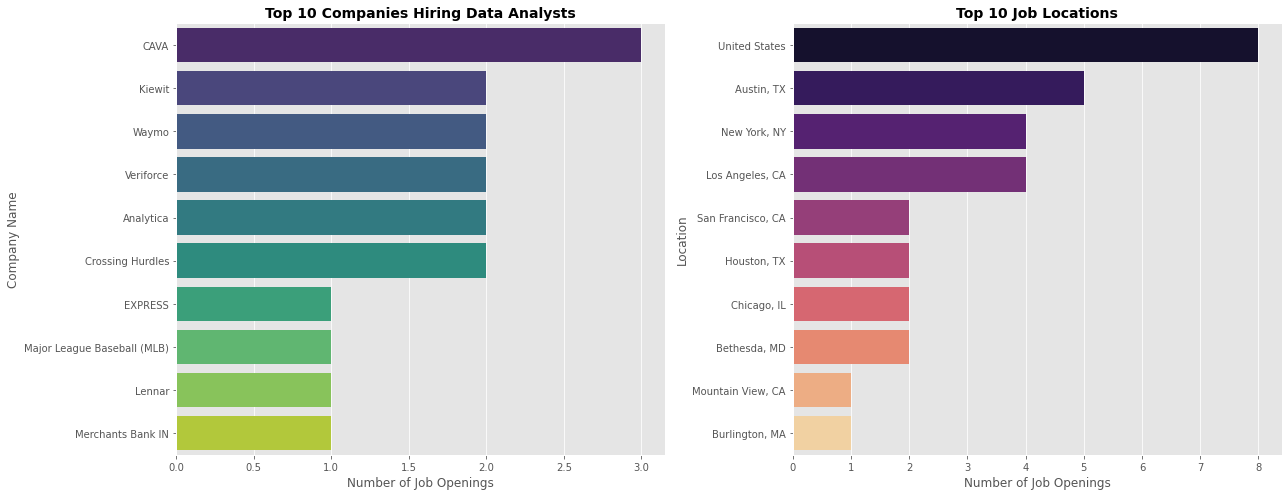

------------------------------------------------------------
🚀 PROJECT EXECUTION COMPLETE
------------------------------------------------------------
📊 Total Jobs Scraped and Organized: 54
🏢 Top Hiring Companies: CAVA, Kiewit, Waymo
📍 Most Active Job Hubs: United States, Austin, TX, New York, NY
------------------------------------------------------------
💡 INSIGHTS FOR EMPLOYERS:
1. The market shows a high demand for Data Analysts in United States.
2. Leading recruiters in this sector are CAVA and Kiewit.
3. Data collection was automated and successfully bypassed initial filters.
------------------------------------------------------------


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 3: DATA VISUALIZATION (Professional Version)
# ==========================================

# Use a globally recognized professional style
plt.style.use('ggplot')

# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Top 10 Companies Hiring ---
# We group by company and count the occurrences
top_companies = df_final_master['Company'].value_counts().head(10)

sns.barplot(x=top_companies.values, y=top_companies.index, ax=ax[0], palette='viridis')
ax[0].set_title('Top 10 Companies Hiring Data Analysts', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Number of Job Openings')
ax[0].set_ylabel('Company Name')

# --- Plot 2: Top 10 Job Locations ---
# We group by location and count the occurrences
top_locations = df_final_master['Location'].value_counts().head(10)

sns.barplot(x=top_locations.values, y=top_locations.index, ax=ax[1], palette='magma')
ax[1].set_title('Top 10 Job Locations', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Number of Job Openings')
ax[1].set_ylabel('Location')

# Final layout adjustment
plt.tight_layout()
plt.show()

# ==========================================
# STEP 4: FINAL SUMMARY REPORT (For Portfolio)
# ==========================================

print("-" * 60)
print("🚀 PROJECT EXECUTION COMPLETE")
print("-" * 60)
print(f"📊 Total Jobs Scraped and Organized: {len(df_final_master)}")
print(f"🏢 Top Hiring Companies: {', '.join(top_companies.index[:3])}")
print(f"📍 Most Active Job Hubs: {', '.join(top_locations.index[:3])}")
print("-" * 60)
print("💡 INSIGHTS FOR EMPLOYERS:")
print(f"1. The market shows a high demand for Data Analysts in {top_locations.index[0]}.")
print(f"2. Leading recruiters in this sector are {top_companies.index[0]} and {top_companies.index[1]}.")
print(f"3. Data collection was automated and successfully bypassed initial filters.")
print("-" * 60)